In [1]:
import torch
import numpy as np
from sys import path
import os
path.append("./src")
from model_3d import CosmoCNN


In [2]:
train = 'TNG'
test = 'SIMBA'

train_test = f'TRAIN_{train}_TEST_{test}'

os.makedirs(train_test, exist_ok=True)

In [3]:
ROOT = "/Users/hyp0515/Desktop/a3_project/new/"

RESULT_DIR = ROOT + f"results/{train}_MP_BATCHSIZE32_LOG"

MODEL_PATH = f"{RESULT_DIR}/best_model.pt"
NORM_PATH = f"{RESULT_DIR}/normalization.npz"
SPLIT_PATH = f"{RESULT_DIR}/split_indices.npz"
HISTORY_PATH = f"{RESULT_DIR}/loss_history.npz"

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CosmoCNN().to(device)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)

model.eval()
print("Best model loaded.")

Best model loaded.


In [5]:
norm = np.load(NORM_PATH)

x_mean = norm["x_mean"]
x_std  = norm["x_std"]

y_mean = norm["y_mean"]
y_std  = norm["y_std"]

print("x_mean =", x_mean)
print("x_std  =", x_std)
print("y_mean =", y_mean)
print("y_std  =", y_std)

x_mean = 7.361406871031568
x_std  = 3.8756760255807765
y_mean = [[ 0.3000535   0.7984735  -0.00243083 -0.00923413  0.00267841 -0.00352503]]
y_std  = [[0.11516783 0.115152   0.34645373 0.34440643 0.17457439 0.17512528]]


In [6]:
split = np.load(SPLIT_PATH)

train_idx = split["train_idx"]
val_idx   = split["val_idx"]
test_idx  = split["test_idx"]

print("Train:", len(train_idx))
print("Val  :", len(val_idx))
print("Test :", len(test_idx))

Train: 800
Val  : 100
Test : 100


In [7]:
# M_TNG = np.load(
#     "../data/OFFICIAL/Maps_Mtot_IllustrisTNG_LH_z=0.00.npy",
#     mmap_mode="r"
# ).reshape(1000, 15, 256, 256)

# cosmos_params = np.loadtxt(
#     "../data/OFFICIAL/params_LH_IllustrisTNG.txt"
# )



if test == 'TNG':
    k = 0
else:
    k = 1

test_sim = ['IllustrisTNG', 'SIMBA'][k]

ROOT = "/Users/hyp0515/data/a3/CAMELS_multifield/"
M_MAP_FILE = ROOT + f"Maps_Mtot_{test_sim}_LH_z=0.00.npy"
P_MAP_FILE = ROOT + f"Maps_P_{test_sim}_LH_z=0.00.npy"
PARAM_FILE = ROOT + f"params_LH_{test_sim}.txt"

NUM_EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 1e-3

N_SIM = 1000
N_MAPS_PER_SIM = 15

RANDOM_SEED = 42

print("Loading maps...", flush=True)

M_TNG = np.load(
    M_MAP_FILE,
    mmap_mode="r"
)


M_TNG = M_TNG.reshape(
    N_SIM,
    N_MAPS_PER_SIM,
    256,
    256
)

print(
    "Map shape:",
    M_TNG.shape,
    flush=True
)


P_TNG = np.load(
    P_MAP_FILE,
    mmap_mode="r"
)


P_TNG = P_TNG.reshape(
    N_SIM,
    N_MAPS_PER_SIM,
    256,
    256
)

print(
    "Map shape:",
    M_TNG.shape,
    flush=True
)



cosmos_params = np.loadtxt(
    PARAM_FILE
)


print(
    "Parameter shape:",
    cosmos_params.shape,
    flush=True
)


Loading maps...
Map shape: (1000, 15, 256, 256)
Map shape: (1000, 15, 256, 256)
Parameter shape: (1000, 6)


In [8]:
MP_TNG = np.stack((M_TNG, P_TNG), axis=2)
# log image
MP_TNG = np.log10(MP_TNG)

MP_TNG.shape

(1000, 15, 2, 256, 256)

In [9]:
# Apply log10 to all parameters except omega_m and sigma_8
cosmos_params[:, 2:] = np.log10(cosmos_params[:, 2:])

params_n = (
    cosmos_params - y_mean
) / y_std

In [10]:
import torch
from torch.utils.data import Dataset

class CAMELSDataset(Dataset):

    def __init__(
        self,
        maps,
        params,
        sim_indices,
        x_mean,
        x_std
    ):
        self.maps = maps
        self.params = params
        self.sim_indices = sim_indices
        self.x_mean = x_mean
        self.x_std = x_std

    def __len__(self):
        return len(self.sim_indices) * 15

    def __getitem__(self, idx):

        sim_local = idx // 15
        map_id = idx % 15

        sim_id = self.sim_indices[sim_local]

        x = self.maps[sim_id, map_id]
        y = self.params[sim_id]

        x = (x - self.x_mean) / self.x_std

        x = torch.as_tensor(
            x,
            dtype=torch.float32
        )

        y = torch.as_tensor(
            y,
            dtype=torch.float32
        )

        return x, y

In [11]:
from torch.utils.data import DataLoader

test_dataset = CAMELSDataset(
    MP_TNG,
    params_n,
    test_idx,
    x_mean,
    x_std
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [12]:
pred_list = []

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)

        pred = model(X)

        pred_list.append(
            pred.cpu().numpy()
        )

In [13]:
pred_n = np.concatenate(
    pred_list,
    axis=0
)

print(pred_n.shape)

(1500, 6)


In [14]:
pred = (
    pred_n * y_std + y_mean
)

In [15]:
pred_sim = pred.reshape(
    len(test_idx),
    15,
    6
).mean(axis=1)

In [16]:
true_sim = cosmos_params[test_idx]

In [17]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

names = [
    "Omega_m",
    "sigma_8",
    "A_SN1",
    "A_AGN1",
    "A_SN2",
    "A_AGN2"
]

RMSE = []
MAE = []
R2 = []


for j, name in enumerate(names):

    true = true_sim[:, j]
    pred_j = pred_sim[:, j]

    rmse = np.sqrt(
        mean_squared_error(
            true,
            pred_j
        )
    )

    mae = mean_absolute_error(
        true,
        pred_j
    )

    r2 = r2_score(
        true,
        pred_j
    )


    RMSE.append(rmse)
    MAE.append(mae)
    R2.append(r2)

    print(
        f"{name:8s}  "
        f"RMSE={rmse:.4f}  "
        f"MAE={mae:.4f}  "
        f"R2={r2:.4f}"
    )

Omega_m   RMSE=0.0762  MAE=0.0673  R2=0.5405
sigma_8   RMSE=0.0977  MAE=0.0779  R2=0.3017
A_SN1     RMSE=2.2463  MAE=2.0546  R2=-44.2875
A_AGN1    RMSE=0.4999  MAE=0.4061  R2=-1.1036
A_SN2     RMSE=0.1780  MAE=0.1385  R2=-0.1381
A_AGN2    RMSE=0.2983  MAE=0.2438  R2=-1.7522


In [18]:
np.savez(
    f'./{train_test}/stats.npz',
    NAME = names,
    RMSE=RMSE,
    MAE=MAE,
    R2=R2
)

for i, name in enumerate(names):
    np.savez(
        f'./{train_test}/{name}_true_predict.npz',
        TRUE=true_sim[:, i],
        PRED=pred_sim[:, i]
    )

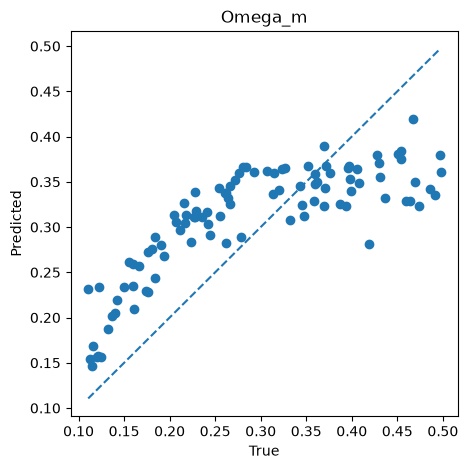

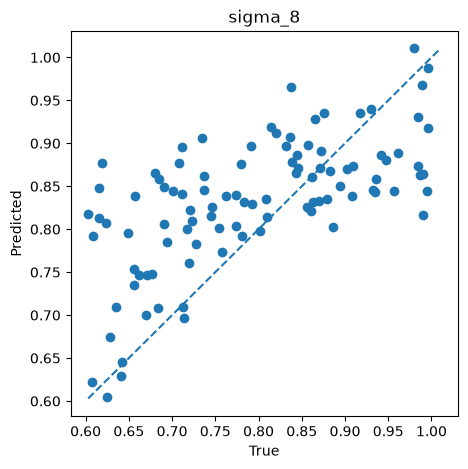

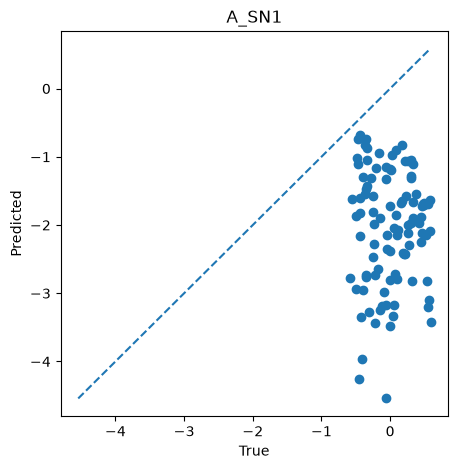

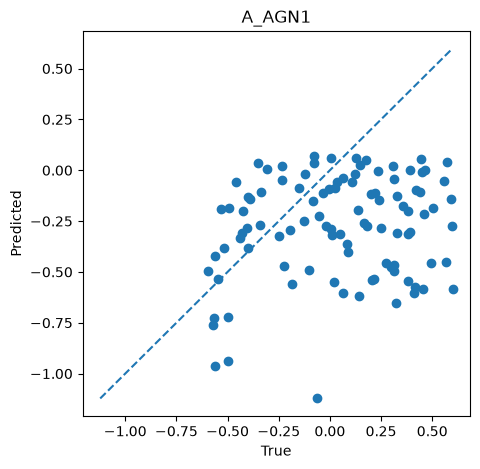

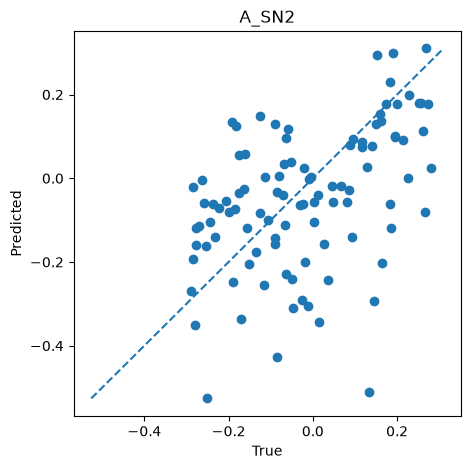

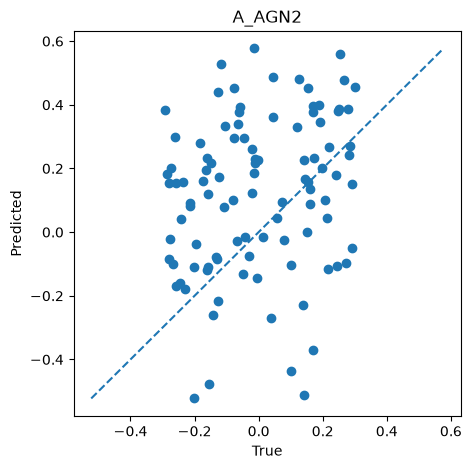

In [19]:
import matplotlib.pyplot as plt

for j, name in enumerate(names):

    true = true_sim[:, j]
    pred_j = pred_sim[:, j]

    vmin = min(
        true.min(),
        pred_j.min()
    )

    vmax = max(
        true.max(),
        pred_j.max()
    )

    plt.figure(figsize=(5, 5))

    plt.scatter(
        true,
        pred_j
    )

    plt.plot(
        [vmin, vmax],
        [vmin, vmax],
        "--"
    )

    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(name)

    plt.show()

In [20]:
history = np.load(
    HISTORY_PATH
)

train_loss = history["train_loss"]
val_loss = history["val_loss"]

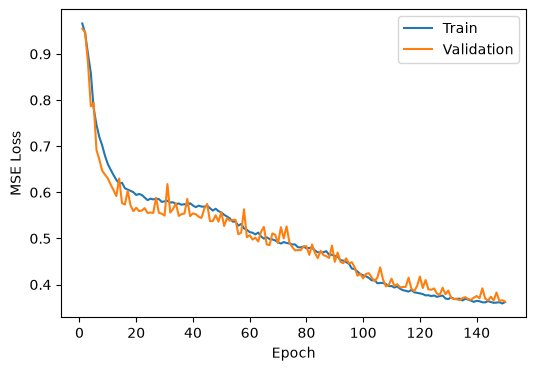

In [21]:
plt.figure(figsize=(6, 4))

plt.plot(
    np.arange(1, len(train_loss)+1),
    train_loss,
    label="Train"
)

plt.plot(
    np.arange(1, len(val_loss)+1),
    val_loss,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.show()

In [22]:
best_epoch = np.argmin(val_loss) + 1

print("Best epoch =", best_epoch)
print("Best val loss =", val_loss[best_epoch - 1])

Best epoch = 150
Best val loss = 0.362956663608551
